# 第5周 b｜删失与Kaplan–Meier

学习目标：观察时间、事件状态、右删失、风险集、1−S(t)。

> **本周怎么学**：先学精讲 `w05a_km_basics.ipynb`，再做这份**工程实践**。

__数据：默认使用官方 PRIME-CVD 5 万人数据__（`python run.py download` 下载，来源与 MD5 核验记录在 `data/raw/manifest.json`）。把 `MODE` 改成 `"demo"` 可以切换到离线演示数据，但演示数据是另外生成的，**不是 PRIME-CVD**，结果不能当作官方结果。

本周验收：用一名随访2年无事件者解释未知五年状态。

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
from IPython.display import display

# 从项目根目录、notebooks目录或其他项目内目录启动均可。
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run.py").exists()), None)
if ROOT is None:
    raise RuntimeError("请在解压后的项目目录中启动 Jupyter。")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from primecvd.common import load_config, provenance_label
from primecvd.pipeline import prepare
from primecvd.splitting import select_split

MODE = "official"  # 官方数据；离线练习或跑测试时可改为 "demo"（演示数据不是 PRIME-CVD）
cfg = load_config(ROOT / "configs" / f"{MODE}.json")
cfg["output_dir"] = f"outputs/notebooks_{MODE}"
print(provenance_label(cfg))
df, splits = prepare(cfg)
train = select_split(df, splits, "train")
valid = select_split(df, splits, "valid")
# 不创建test DataFrame；模型试验只使用train和valid。
print("队列、训练集、验证集：", len(df), len(train), len(valid))

# 命令行绘图模块采用无窗口后端；在Notebook中显式启用行内图像。
get_ipython().run_line_magic("matplotlib", "inline")
from primecvd import pubplot as pp   # 与精讲篇相同的顶刊作图风格（在启用行内图像之后设置）
pp.setup()

OFFICIAL SOURCE FILES / 官方下载文件
队列、训练集、验证集： 50000 35000 7500


## 先认识右删失
`cvd_event=0`表示随访结束时尚未观察到事件。假设一个人只随访了2年，他的五年状态未知。生存分析同时使用观察时间和事件状态，而不是把他强行标为五年阴性。

In [2]:
h = cfg["horizon_years"]
early = train.cvd_event.eq(0) & train.cvd_time.lt(h)
print("预测时间（年）：", h)
print("训练集中五年前删失人数：", int(early.sum()))
display(train.groupby("cvd_event").cvd_time.agg(["count", "min", "median", "max"]))

预测时间（年）： 5.0
训练集中五年前删失人数： 19275


,count,min,median,max
cvd_event,,,,
0,33594,2.677789,4.902383,7.307214
1,1406,0.009961,2.164291,5.906984


观察到事件的人数比例（不是五年风险）： 0.04017142857142857
1-KM(h)及其点态95%CI： (0.04038310079310692, np.float64(0.038307413820495295), np.float64(0.04256874977852554))


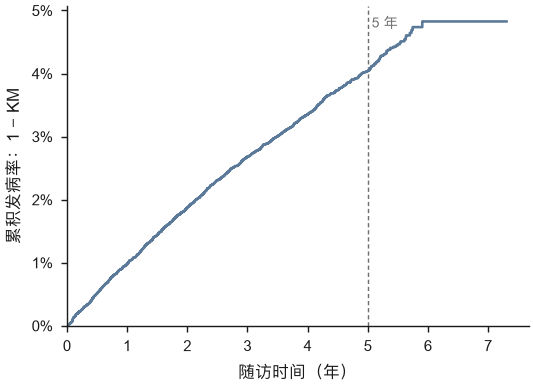

In [3]:
from primecvd.metrics import KaplanMeier
km = KaplanMeier.fit(train.cvd_time, train.cvd_event)
print("观察到事件的人数比例（不是五年风险）：", train.cvd_event.mean())
print("1-KM(h)及其点态95%CI：", km.risk_ci(h))
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=pp.size(pp.SINGLE, 62))
# 画"累积发病率 1 − KM"（向上），事件率低时比"生存率"（向下、挤在 95%–100%）更容易读
ax.step(np.r_[0, km.times], np.r_[0, 1 - km.survival], where="post", color=pp.NEUTRAL)
pp.ref_line(ax, h, label=f"{h:g} 年", label_pos=0.97)
ax.set(xlabel="随访时间（年）", ylabel="累积发病率：1 − KM", xlim=(0, None), ylim=(0, None))
pp.percent_axis(ax)
plt.show()

KM估计需要合理的删失假设。图形只是未调整描述，不自动表示分组造成的因果差异。对超出随访支持的时间点，本项目不会给出可靠性保证。

## 独立练习
手算三个人的小例子：1年发生事件、2年删失、3年发生事件。列出每次事件前的风险集人数。再按基线糖尿病画两条训练集曲线，解释风险集随时间减少的含义。

---
本周复盘：请用自己的话记录一个学会的概念、一个发现的错误和一个待解决问题。

特别提醒：cvd_event=0不等于已知五年阴性。